# 17.2 · Running backgrounds and adaptation

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain running backgrounds and adaptation using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[14 · Classical Segmentation](../../14-segmentation-classical/README.md), [15 · Video Processing](../../15-video-processing/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Motion detection asks where the scene changes over time. It does not identify object categories or preserve identity. The simplest useful systems compare frames or maintain a slowly changing background and then clean a foreground mask.

## 2. Intuition

An exponential running average updates each background pixel with a weighted portion of the current frame. A large update rate adapts quickly but absorbs stopped objects; a small rate keeps old conditions longer. Updating only likely background regions can reduce contamination, but classification errors can then freeze the model.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 17
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
B_t=(1-\alpha)B_{t-1}+\alpha I_t
$$

Bt is the updated background, It the current frame and α the update rate. For previous background 100, current intensity 140 and α=0.1, the new estimate is 104.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
previous, current, alpha = 100.0, 140.0, 0.1
background = (1 - alpha) * previous + alpha * current
assert np.isclose(background, 104)
print(background)

104.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The generated sequence supplies an initial background and moving foreground. The lab compares absolute differences, a running mean and OpenCV MOG2 masks under a fixed seed.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def motion(lesson, seed, amount):
    frames = list(video_frames())
    background = np.zeros(frames[0].shape, np.float32)
    model = cv2.createBackgroundSubtractorMOG2(
        history=20, varThreshold=16 * amount, detectShadows=False
    )
    energy = []
    for frame in frames:
        mask = model.apply(frame)
        difference = np.abs(frame.astype(float) - background).mean(2) > 20
        background = 0.95 * background + 0.05 * frame
        energy.append(int(difference.sum()))
    return Result(
        "17 · Motion masks and adaptive background",
        {
            "Current frame": frames[-1],
            "Running-mean foreground": difference,
            "MOG2 foreground": mask,
            "Adjacent difference": cv2.absdiff(frames[-1], frames[-2]),
        },
        curves={"Foreground pixels per frame": energy},
        metrics={"last_foreground_pixels": energy[-1]},
        notes="Camera motion and shadows violate a stationary-background assumption. Motion is not a semantic object label.",
    )

{
  "last_foreground_pixels": 167
}
Camera motion and shadows violate a stationary-background assumption. Motion is not a semantic object label.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/tracking.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.tracking import KalmanTracker

display(Code(inspect.getsource(KalmanTracker), language="python"))

class KalmanTracker:
    """Track XY centers; anonymous IDs, constant-velocity model and distance gating.

    This teaches SORT's ingredients, but is not a reproduction of SORT/DeepSORT:
    there is no box-size state or learned appearance embedding.
    """

    def __init__(self, gate=25.0, max_missed=4):
        self.gate, self.max_missed = gate, max_missed
        self.tracks = []
        self.next_identity = 1

    def update(self, centers, dt=1.0):
        centers = np.asarray(centers, float).reshape(-1, 2)
        if dt <= 0:
            raise ValueError("dt must be positive.")
        f = np.array([[1, 0, dt, 0], [0, 1, 0, dt], [0, 0, 1, 0], [0, 0, 0, 1.0]])
        h = np.eye(2, 4)
        q = (
            np.array(
                [
                    [dt**4 / 4, 0, dt**3 / 2, 0],
                    [0, dt**4 / 4, 0, dt**3 / 2],
                    [dt**3 / 2, 0, dt**2, 0],
                    [0, dt**3 / 2, 0, dt**2],
                ]
            )
            * 0.1
        )
        for track in self.tracks:
            track.state = f @ track.state
            track.covariance = f @ track.covariance @ f.T + q
            track.missed += 1
        matched = set()
        if self.tracks and len(centers):
            costs = np.linalg.norm(
                np.array([t.state[:2] for t in self.tracks])[:, None] - centers, axis=2
            )
            rows, cols = linear_sum_assignment(np.where(costs <= self.gate, costs, 1e6))
            for row, col in zip(rows, cols, strict=True):
                if costs[row, col] > self.gate:
                    continue
                track = self.tracks[row]
                residual = centers[col] - h @ track.state
                s = h @ track.covariance @ h.T + np.eye(2) * 2
                gain = np.linalg.solve(s, h @ track.covariance).T
                track.state += gain @ residual
                a = np.eye(4) - gain @ h
                track.covariance = a @ track.covariance @ a.T + gain @ (np.eye(2) * 2) @ gain.T
                track.missed = 0
                matched.add(col)
        self.tracks = [t for t in self.tracks if t.missed <= self.max_missed]
        for index, center in enumerate(centers):
            if index not in matched:
                self.tracks.append(
                    Track(self.next_identity, np.r_[center, 0.0, 0.0], np.eye(4) * 10)
                )
                self.next_identity += 1
        for track in self.tracks:
            track.history.append(track.state[:2].tolist())
            track.history = track.history[-100:]
        return self.tracks

## 8. Experiment

Stop the object midway and vary adaptation rate. Measure how long it remains foreground and how long a ghost remains after it leaves.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "last_foreground_pixels": 167
  },
  "second_seed": {
    "last_foreground_pixels": 167
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

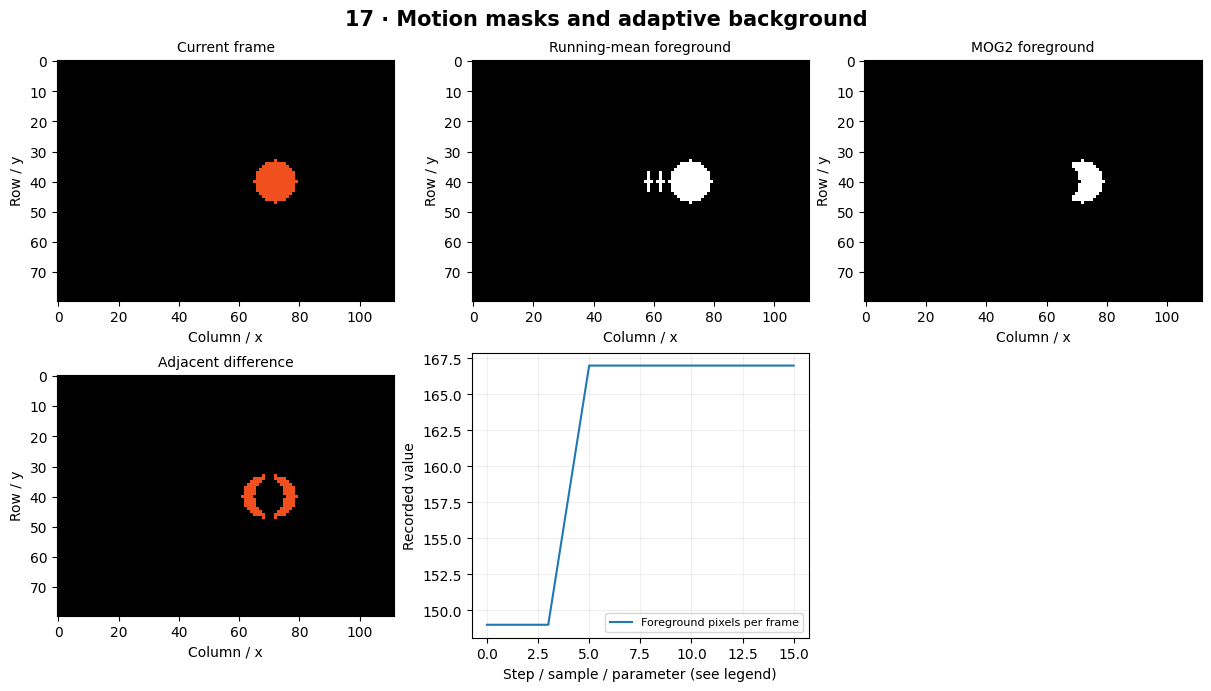

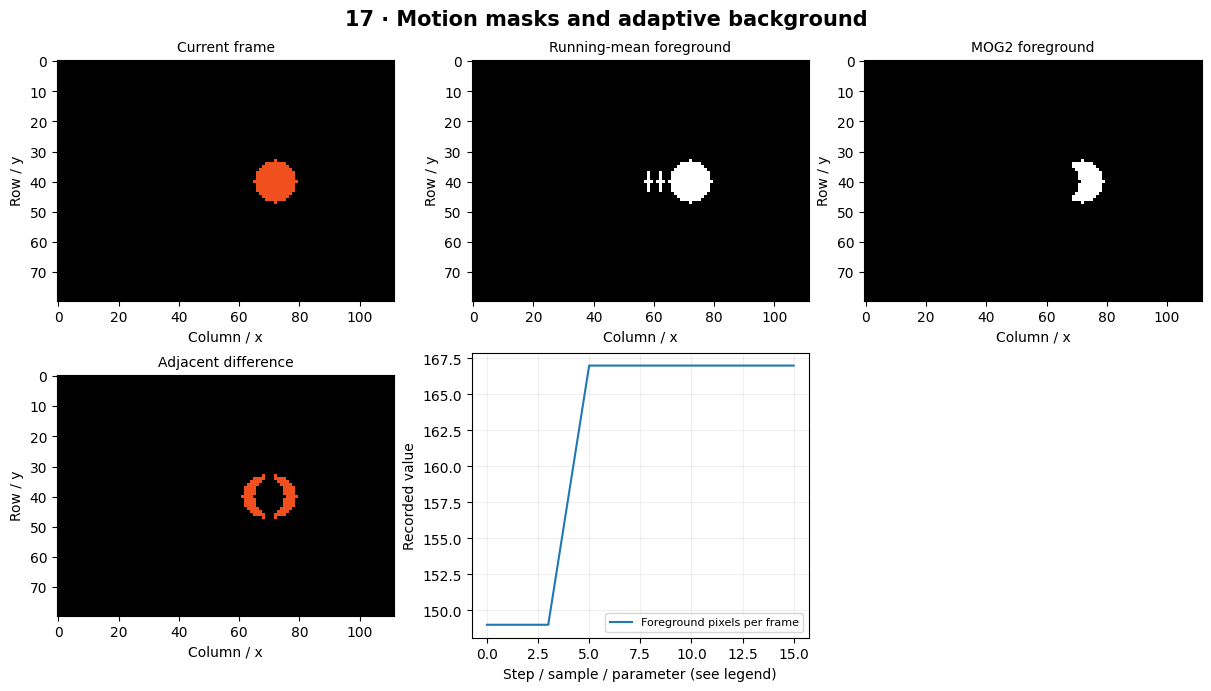

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Motion Detector**. Detect scene change without confusing it with object identity. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Global lighting changes resemble motion. A binary foreground mask does not distinguish one object from two touching objects.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Stop the object midway and vary adaptation rate. Measure how long it remains foreground and how long a ghost remains after it leaves.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Design a motion-triggered recorder with warm-up, hysteresis and an explicit false-trigger test under lighting changes.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

An exponential running average updates each background pixel with a weighted portion of the current frame. A large update rate adapts quickly but absorbs stopped objects; a small rate keeps old conditions longer. Updating only likely background regions can reduce contamination, but classification errors can then freeze the model.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **MOG2, shadows and failure analysis** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/d1/dc5/tutorial_background_subtraction.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)